In [2]:
import os
import sys
print(os.getcwd())

patient_pipeline_path = "c:/Users/Soz/OneDrive - Radboud Universiteit/Bureaublad/BSc_Thesis/Code/BSc_Thesis_Project/ERP_analysis_code"

# Go up until you reach the root of your project where `patient_pipeline/` lives
# Adjust this path depending on your folder depth
sys.path.append(os.path.abspath(patient_pipeline_path))  # or "../../", "../../../", etc.

from patient_pipeline.results.results_functions import extract_ews_v3, extract_tws_v3
from patient_pipeline.results.db import patients_db

import pickle
import numpy as np
import matplotlib.pyplot as plt
# from patient_pipeline.results.results_functions import extract_ews_v3, extract_tws_v3
# from patient_pipeline.results.db import patients_db



c:\Users\Soz\OneDrive - Radboud Universiteit\Bureaublad\BSc_Thesis\Code\BSc_Thesis_Project\ERP_analysis_code\patient_pipeline\results_UC


dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])
dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])
dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])
dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])


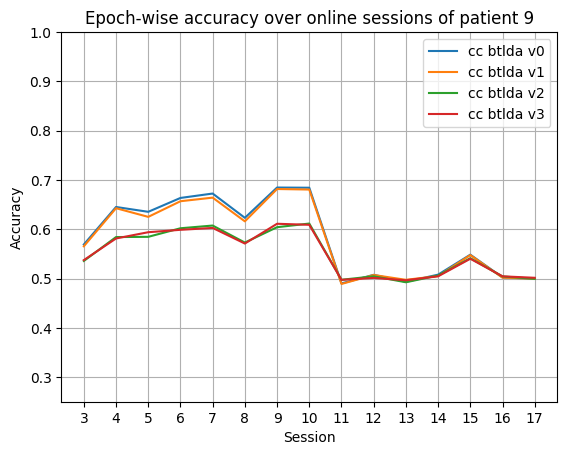

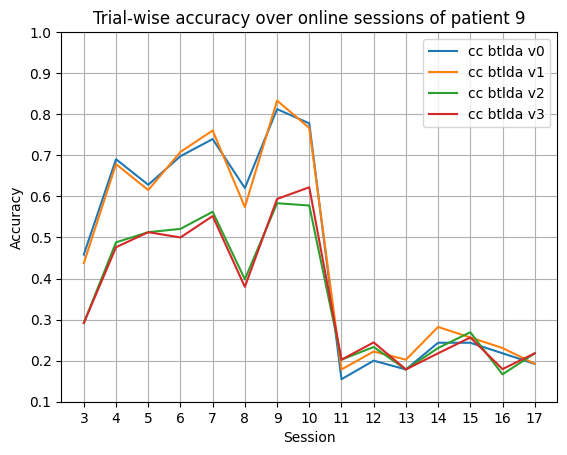

In [5]:
p =9
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

# tr long ival range
v = 0
with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
    p_cc_v0 = pickle.load(f) 

print(p_cc_v0.keys())

v = 1
with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
    p_cc_v1 = pickle.load(f) 

print(p_cc_v1.keys())

v = 2
with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
    p_cc_v2 = pickle.load(f) 

print(p_cc_v2.keys())

v = 3
with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
    p_cc_v3 = pickle.load(f) 

print(p_cc_v3.keys())


ews_cc_v0= extract_ews_v3(performances= p_cc_v0, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v0 = extract_tws_v3(performances= p_cc_v0, patient_nr=p, last_online_session=lon, strategy="cc")

ews_cc_v1= extract_ews_v3(performances= p_cc_v1, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v1 = extract_tws_v3(performances= p_cc_v1, patient_nr=p, last_online_session=lon, strategy="cc")


ews_cc_v2= extract_ews_v3(performances= p_cc_v2, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v2 = extract_tws_v3(performances= p_cc_v2, patient_nr=p, last_online_session=lon, strategy="cc")
ews_cc_v3= extract_ews_v3(performances= p_cc_v3, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v3 = extract_tws_v3(performances= p_cc_v3, patient_nr=p, last_online_session=lon, strategy="cc")

# Plot 1: epoch-wise
plt.figure()
plt.plot(ews_cc_v0, label="cc btlda v0")
plt.plot(ews_cc_v1, label="cc btlda v1")
plt.plot(ews_cc_v2, label="cc btlda v2")
plt.plot(ews_cc_v3, label="cc btlda v3")
plt.title(f"Epoch-wise accuracy over online sessions of patient {p}")
plt.legend()
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0,lon-2),np.arange(3,lon+1))
plt.ylim((0.25,1))
plt.grid()


# Plot 2: Trial-wise acc 

plt.figure()

plt.plot(tws_cc_v0, label="cc btlda v0")
plt.plot(tws_cc_v1, label="cc btlda v1")
plt.plot(tws_cc_v2, label="cc btlda v2")
plt.plot(tws_cc_v3, label="cc btlda v3")

plt.title(f"Trial-wise accuracy over online sessions of patient {p}")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.1,1))
plt.grid()
plt.xticks(np.arange(0,lon-2),np.arange(3,lon+1))
#plt.yticks(np.arange(0,1.1,0.1))
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
#plt.xticks(np.arange(0,last_on_session-2),np.arange(3,last_on_session+1))
plt.legend()
plt.show()

dict_keys([0, 1, 2, 3])
UC_mean: 0.5 - UC_cov: 0.5
UC_mean: 0.5 - UC_cov: 1.0
UC_mean: 1.0 - UC_cov: 0.5
UC_mean: 1.0 - UC_cov: 1.0


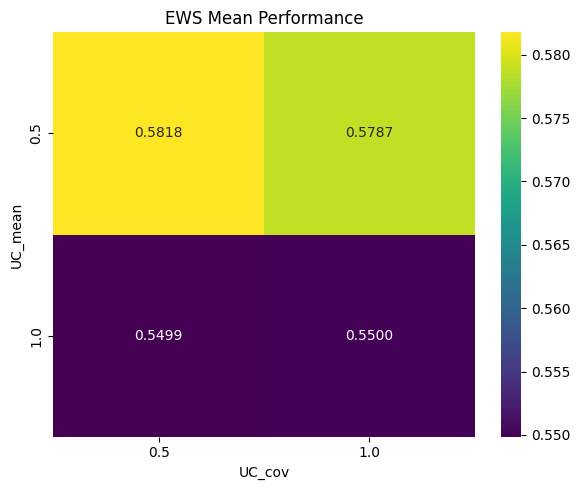

In [84]:
import pandas as pd
import seaborn as sns


def create_dict_results_UC_pairs(p, lon):
    with open(f'versions.pkl', 'rb') as f:
        versions_dict = pickle.load(f) 

    print(versions_dict.keys())
    #UC_means = []
    #UC_covs = []
    UC_pairs = []
    data = []

    for v,version in enumerate(versions_dict.keys()):
        
        UC_m = versions_dict.get(version).get("UC_mean")
        UC_c = versions_dict.get(version).get("UC_cov")

        with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
            p_version_scores = pickle.load(f) 

        ews_cc= extract_ews_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")
        tws_cc = extract_tws_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")

        data.append({
            "v": v,
            "UC_mean": UC_m,
            "UC_cov": UC_c,
            "EWS_mean": ews_cc.mean(),
            "TWS_mean": tws_cc.mean()
        })

        print(f"UC_mean: {UC_m} - UC_cov: {UC_c}")
        #UC_means.append(UC_m)
        #UC_covs.append(UC_c)
        UC_pairs.append(np.array([UC_m, UC_c]))

    return data

def create_dataframe(dict):
    df_long = pd.DataFrame(dict)
    return df_long

# Use
p = 9
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

data_dict = create_dict_results_UC_pairs(p=p, lon=lon)
df = create_dataframe(data_dict)
df.to_csv("cc_pairs_results.csv")

pivot_ews = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(pivot_ews, annot=True, fmt=".4f", cmap="viridis")
plt.title("EWS Mean Performance")
plt.ylabel("UC_mean")
plt.xlabel("UC_cov")
plt.tight_layout()
plt.show()

In [74]:
print(all_means)
print(np.array(all_means)[0,:])
print(UC_pairs)


[[0.58176727 0.5786674 ]
 [0.54985415 0.55004894]]
[0.58176727 0.5786674 ]
[array([0.5, 0.5]), array([0.5, 1. ]), array([1. , 0.5]), array([1., 1.])]


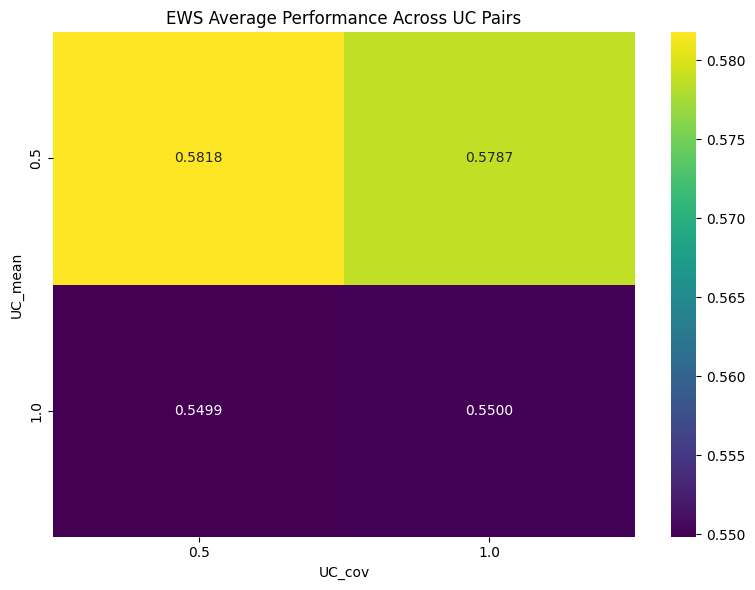

In [ ]:

# Results
import seaborn as sns

# Plot
plt.figure(figsize=(8, 6))
ax = sns.heatmap(all_means, annot=True, fmt=".4f", cmap="viridis",
                 xticklabels=np.unique(UC_pairs[:,1]), yticklabels=np.unique(UC_pairs[:,0]))

# Labels
#ax.invert_yaxis()
plt.xlabel("UC_cov")
plt.ylabel("UC_mean")
plt.title("EWS Average Performance Across UC Pairs")
plt.tight_layout()
plt.show()
